In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("./datasets/Phishing_Email_1/Phishing_Email.csv")
df.head(5)

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [3]:
df = df.drop(labels="Unnamed: 0", axis=1)
df.head(5)

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [4]:
df.head(5)

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [5]:
import numpy as np

df["Email Type"] = np.where(df['Email Type'] == "Safe Email", 0, 1)
df.head(10)

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1
5,global risk management operations sally congra...,0
6,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",0
7,"entourage , stockmogul newsletter ralph velez ...",1
8,"we owe you lots of money dear applicant , afte...",1
9,re : coastal deal - with exxon participation u...,0


In [6]:
df = df.rename(columns={"Email Text": "text", "Email Type": "email_type"})
df.head(5)

,text,email_type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


In [7]:
print(df.isnull())

        text  email_type
0      False       False
1      False       False
2      False       False
3      False       False
4      False       False
...      ...         ...
18645  False       False
18646  False       False
18647  False       False
18648  False       False
18649  False       False

[18650 rows x 2 columns]


In [8]:
df.describe()

,email_type
count,18650.000000
mean,0.392922
std,0.488413
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        18634 non-null  object
 1   email_type  18650 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 291.5+ KB


In [10]:
df.isnull().sum()

text          16
email_type     0
dtype: int64

In [11]:
df = df.dropna(how="any", axis=0)

In [12]:
df.isnull().sum()

text          0
email_type    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(1096)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [59]:
import matplotlib.pyplot as plt

In [70]:
plt.figure(facecolor="#0B1120")
plt.rcParams['axes.facecolor'] = "#0B1120"
plt.rcParams['figure.facecolor'] = "#0B1120"
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['grid.color'] = '#444444'
plt.rcParams['xtick.color'] = '#bbbbbb'
plt.rcParams['ytick.color'] = '#bbbbbb'

<Figure size 640x480 with 0 Axes>

In [71]:
df['email_type'].value_counts()

email_type
0    10980
1     6558
Name: count, dtype: int64

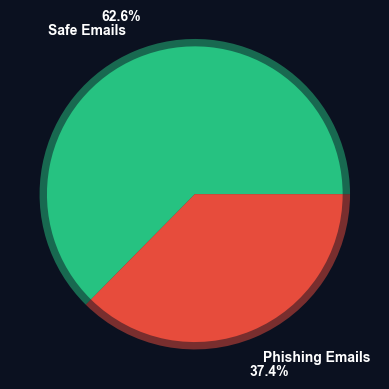

In [72]:
counts = df['email_type'].value_counts()

# Glow layer
plt.pie(
    counts,
    radius=1.05,
    colors=["#26C28180", "#E74C3C80"],  
)

plt.pie(counts, labels=["Safe Emails", "Phishing Emails"], 
        autopct='%1.1f%%', 
        colors=["#26C281", "#E74C3C"], 
        textprops={'color':'white', 'fontweight':'bold'},
        pctdistance=1.3,
        labeldistance=1.2
       )
plt.show()

In [73]:
df['num_links'] = df['text'].str.count('http')
df['num_excl'] = df['text'].str.count('!')
df['num_caps'] = df['text'].str.count(r'[A-Z]')
df['length'] = df['text'].str.len()

In [74]:
df.head()

,text,email_type,num_links,num_excl,num_caps,length
0,6 1100 disc uniformitarianism 1086 sex lang di...,0,0,0,0,594
1,side galicismos galicismo spanish term names i...,0,0,0,0,287
2,equistar deal tickets still available assist r...,0,0,0,0,786
3,hello hot lil horny toy one dream open minded ...,1,0,0,0,320
4,software incredibly low prices 86 lower draper...,1,0,0,0,361


In [75]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>", "", text)     
    text = re.sub(r"[^a-z0-9 ]", " ", text)    
    text = re.sub(r"\s+", " ", text)             
    return text.strip()

In [76]:
df['text'] = df['text'].apply(clean_text)

In [77]:
df.head(5)

,text,email_type,num_links,num_excl,num_caps,length
0,6 1100 disc uniformitarianism 1086 sex lang di...,0,0,0,0,594
1,side galicismos galicismo spanish term names i...,0,0,0,0,287
2,equistar deal tickets still available assist r...,0,0,0,0,786
3,hello hot lil horny toy one dream open minded ...,1,0,0,0,320
4,software incredibly low prices 86 lower draper...,1,0,0,0,361


In [78]:
from nltk.corpus import stopwords

stop = set(stopwords.words('english'))
df['text'] = df['text'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop])
)

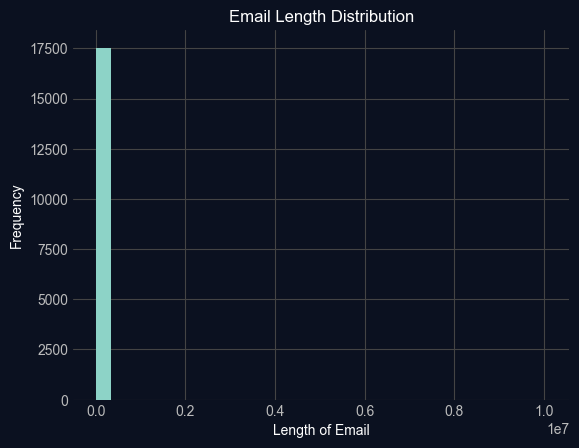

In [100]:
plt.hist(
    df['length'],
    bins=30,
)
plt.title("Email Length Distribution")
plt.xlabel("Length of Email")
plt.ylabel("Frequency")
plt.show()

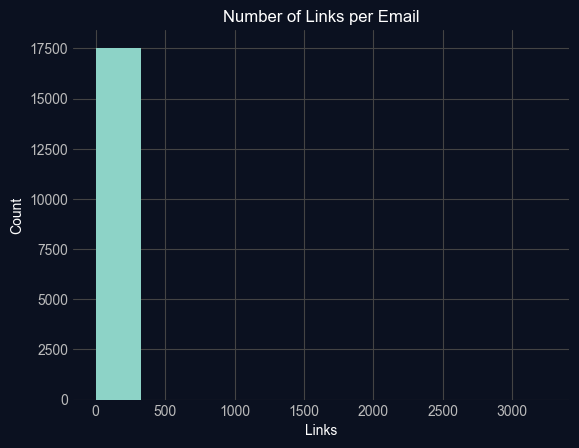

In [101]:
plt.hist(df['num_links'], bins=10)
plt.title("Number of Links per Email")
plt.xlabel("Links")
plt.ylabel("Count")
plt.show()

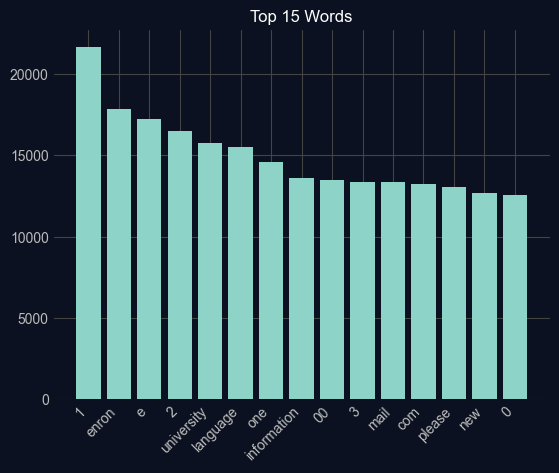

In [102]:
from collections import Counter

words = " ".join(df['text']).split()
common = Counter(words).most_common(15)

labels, values = zip(*common)

plt.bar(labels, values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Words")
plt.show()

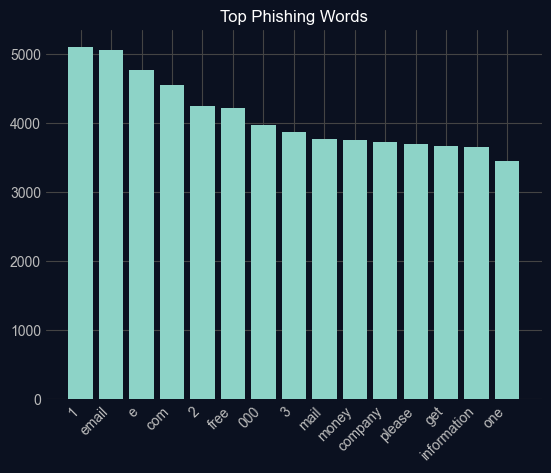

In [103]:
def get_words(df, t):
    return " ".join(df[df['email_type']==t]['text']).split()

phish_words = get_words(df, 1)
phish_common = Counter(phish_words).most_common(15)

labels, values = zip(*phish_common)

plt.bar(labels, values)
plt.xticks(rotation=45, ha='right')
plt.title("Top Phishing Words")
plt.show()

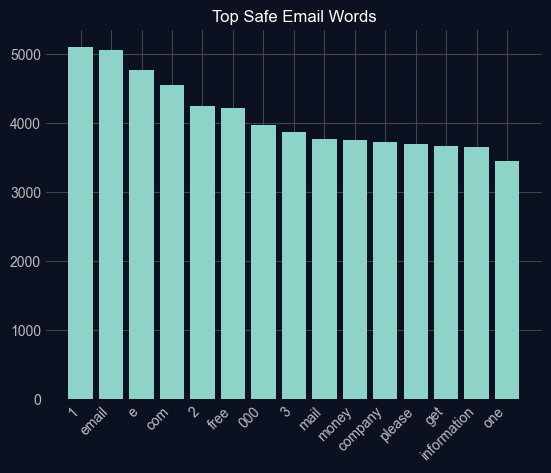

In [104]:
safe_words = get_words(df, 0)
safe_common = Counter(safe_words).most_common(15)

labels, values = zip(*phish_common)

plt.bar(labels, values)
plt.xticks(rotation=45, ha='right')
plt.title("Top Safe Email Words")
plt.show()

In [105]:
phish = Counter(get_words(df,1))
safe_words  = Counter(get_words(df,0))

def clean_counter(c):
    return Counter({w:v for w,v in c.items() if w.isalpha() and len(w)>2})

phish_words = clean_counter(phish)
safe_words  = clean_counter(safe)

print("Top phishing:", phish_words.most_common(20))
print("Top safe:", safe_words.most_common(20))

Top phishing: [('email', 5064), ('com', 4552), ('free', 4214), ('mail', 3766), ('money', 3753), ('company', 3720), ('please', 3695), ('get', 3671), ('information', 3658), ('one', 3446), ('business', 3428), ('time', 3163), ('report', 3025), ('http', 3006), ('new', 2915), ('click', 2808), ('make', 2611), ('order', 2579), ('may', 2445), ('people', 2390)]
Top safe: [('enron', 17840), ('university', 15674), ('language', 15466), ('one', 11163), ('ect', 10899), ('subject', 10265), ('would', 10178), ('information', 9947), ('new', 9785), ('mail', 9559), ('please', 9377), ('com', 8648), ('linguistics', 8146), ('also', 7965), ('conference', 7262), ('may', 7123), ('time', 6830), ('list', 6753), ('like', 6638), ('papers', 6218)]


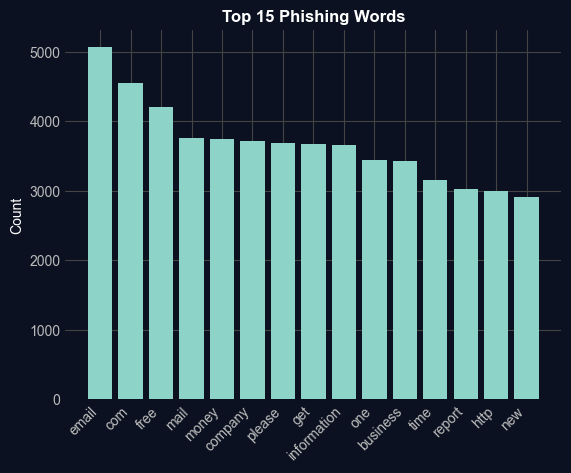

In [106]:
labels, values = zip(*phish_words.most_common(15))

plt.bar(labels, values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Phishing Words", fontweight="bold")
plt.ylabel("Count")
plt.show()

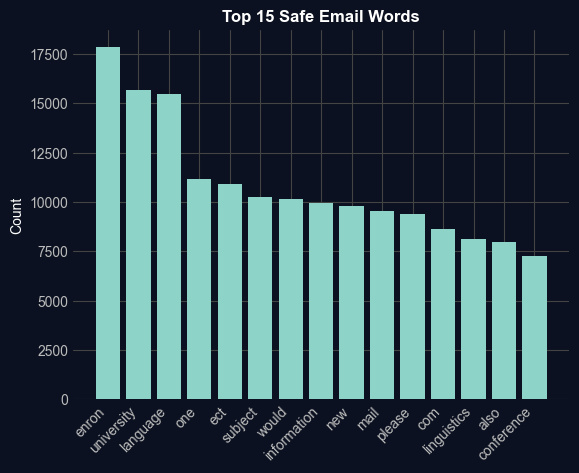

In [107]:
labels, values = zip(*safe_words.most_common(15))

plt.bar(labels, values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Safe Email Words", fontweight="bold")
plt.ylabel("Count")
plt.show()

In [108]:
df.to_csv("cleaned_emails.csv", index=False)